# Capstone — Bayesian Black-Box Optimisation (BBO)
## Imperial College PCMLAI · Stage 2 · 8 Fonksiyon (v5)

**v5 birlesik pipeline:** Pipeline 4 (degenerate kilitleme + fonksiyon bazli AF) + GP iyilestirmeleri (WhiteKernel, log-y).

**Haftalik is akisi:**
1. `CURRENT_WEEK` guncelle
2. Haftalik analiz calistir
3. Email sonuclarini `EMAIL_RESULTS` yaz
4. Veri guncelleme calistir


In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from scipy.optimize import differential_evolution
from scipy.stats import norm, qmc
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel as C
from sklearn.gaussian_process.kernels import Matern, WhiteKernel

warnings.filterwarnings("ignore")
np.random.seed(42)

print("Imports OK")
print(f"  numpy {np.__version__}")


Imports OK
  numpy 2.2.6


## 1. Yapilandirma


In [2]:
DATA_ROOT = Path(".")

# Per-function GP ayarlari. AF (acquisition) secimi STRATEGY + decide_af'ta.
FUNCTIONS = {
    1: {
        "dim": 2, "n_init": 10,
        "description": "Radiation source detection (2D)",
        "notes": "Keskin, seyrek tepe; cogu okuma ~0.",
        "profile": "sparse_peak",
        "gp_alpha": 1e-12, "nu": 0.5,
    },
    2: {
        "dim": 2, "n_init": 10,
        "description": "Noisy ML log-likelihood (2D)",
        "notes": "Gurultulu; WhiteKernel + EI.",
        "profile": "noisy",
        "gp_alpha": 1e-8, "use_white_kernel": True,
    },
    3: {
        "dim": 3, "n_init": 15,
        "description": "Drug discovery — adverse reactions (3D)",
        "notes": "Tum ciktilar negatif; maksimize = sifira en yakin.",
        "profile": "negative",
        "gp_alpha": 1e-6, "nu": 1.5,
    },
    4: {
        "dim": 4, "n_init": 30,
        "description": "Warehouse placement (4D)",
        "notes": "Cok yerel optimum; uzun kesif.",
        "profile": "multimodal",
        "gp_alpha": 1e-4,
    },
    5: {
        "dim": 4, "n_init": 20,
        "description": "Chemical yield — unimodal (4D)",
        "notes": "Tek genis tepe; bulununca hizli exploit.",
        "profile": "unimodal",
        "gp_alpha": 1e-6,
    },
    6: {
        "dim": 5, "n_init": 20,
        "description": "Cake recipe — negative score (5D)",
        "notes": "Negatif skor; sifira yakinlastir.",
        "profile": "negative",
        "gp_alpha": 1e-6,
    },
    7: {
        "dim": 6, "n_init": 30,
        "description": "ML hyperparameter tuning (6D)",
        "notes": "Yuksek boyut; EI dengeli arama.",
        "profile": "high_dim",
        "gp_alpha": 1e-6,
    },
    8: {
        "dim": 8, "n_init": 40,
        "description": "8-parameter ML optimisation (8D)",
        "notes": "Karmasik yuksek boyutlu arama.",
        "profile": "high_dim",
        "gp_alpha": 1e-5, "nu": 1.5,
    },
}

STRATEGY = {
    1: {
        "name": "Radiation Detection (2D)",
        "af_explore": "uncertainty", "af_exploit": "ucb",
        "kappa_expl": 3.0, "signal_thr": 1e-4,
    },
    2: {"name": "Noisy ML (2D)", "af": "ei", "kappa": None},
    3: {"name": "Drug Discovery (3D)", "af": "ucb", "kappa": 2.576},
    4: {"name": "Warehouse (4D)", "af": "ucb", "kappa": 3.0},
    5: {
        "name": "Chemical Yield (4D)",
        "af_explore": "ucb", "af_exploit": "ucb",
        "kappa_explore": 2.576, "kappa_exploit": 0.5, "signal_thr": 2000.0,
    },
    6: {"name": "Cake Recipe (5D)", "af": "ei", "kappa": None},
    7: {"name": "HP Tuning (6D)", "af": "ei", "kappa": None},
    8: {"name": "8D ML Model", "af": "ucb", "kappa": 2.576},
}

GP_CONFIG = {
    "n_restarts_optimizer": 10,
    "normalize_y": True,
    "length_scale_bounds": (1e-2, 10.0),
    "degenerate_threshold": 8.0,
    "boundary_buffer": 0.02,
    "nu": 2.5,
    "local_explore_radius": 0.15,
    "boundary_penalty_weight": 0.5,
    "sensitive_ls_thr": 0.2,
    "sensitive_bound_k": 2.5,
    "sensitive_bound_min_radius": 0.08,
}

CURRENT_WEEK = 2  # <-- HER HAFTA GUNCELLE (1-13)

print("Configuration loaded")
for fn, cfg in FUNCTIONS.items():
    print(f"  F{fn}: {cfg['dim']}D | {cfg['profile']} | {cfg['description']}")


Configuration loaded
  F1: 2D | sparse_peak | Radiation source detection (2D)
  F2: 2D | noisy | Noisy ML log-likelihood (2D)
  F3: 3D | negative | Drug discovery — adverse reactions (3D)
  F4: 4D | multimodal | Warehouse placement (4D)
  F5: 4D | unimodal | Chemical yield — unimodal (4D)
  F6: 5D | negative | Cake recipe — negative score (5D)
  F7: 6D | high_dim | ML hyperparameter tuning (6D)
  F8: 8D | high_dim | 8-parameter ML optimisation (8D)


## 2. Cekirdek Fonksiyonlar (GP + Acquisition)


In [3]:
def load_data(fn_id):
    base = DATA_ROOT / f"function_{fn_id}"
    X = np.load(base / "initial_inputs.npy")
    Y = np.load(base / "initial_outputs.npy")
    return X, Y


def save_data(fn_id, X, Y):
    base = DATA_ROOT / f"function_{fn_id}"
    base.mkdir(parents=True, exist_ok=True)
    np.save(base / "initial_inputs.npy", X)
    np.save(base / "initial_outputs.npy", Y)
    print(f"  F{fn_id} kaydedildi — {len(Y)} gozlem")


def _transform_y(Y, cfg):
    if cfg.get("log_transform_y") and np.all(Y > 0):
        return np.log(Y), "log"
    return Y.copy(), "none"


def _length_scale_init(X):
    var = np.var(X, axis=0)
    var[var < 1e-6] = 0.1
    return np.sqrt(var)


def fit_gp(X, Y, cfg):
    Y_fit, _ = _transform_y(Y, cfg)
    ls_init = _length_scale_init(X)
    lo, hi = GP_CONFIG["length_scale_bounds"]
    matern = Matern(length_scale=ls_init, length_scale_bounds=(lo, hi), nu=cfg.get("nu", GP_CONFIG["nu"]))
    if cfg.get("use_white_kernel"):
        kernel = C(1.0, (1e-3, 1e3)) * matern + WhiteKernel(
            noise_level=1e-3, noise_level_bounds=(1e-8, 1e-1)
        )
    else:
        kernel = C(1.0, (1e-3, 1e3)) * matern
    gp = GaussianProcessRegressor(
        kernel=kernel,
        alpha=cfg.get("gp_alpha", 1e-6),
        n_restarts_optimizer=GP_CONFIG["n_restarts_optimizer"],
        normalize_y=GP_CONFIG["normalize_y"],
        random_state=42,
    )
    gp.fit(X, Y_fit)
    return gp, Y_fit


def ucb_val(gp, x, kappa=2.576):
    mu, sigma = gp.predict(x.reshape(1, -1), return_std=True)
    return mu[0] + kappa * sigma[0]


def ei_val(gp, x, f_best):
    mu, sigma = gp.predict(x.reshape(1, -1), return_std=True)
    sigma = max(float(sigma[0]), 1e-12)
    z = (mu[0] - f_best) / sigma
    return max((mu[0] - f_best) * norm.cdf(z) + sigma * norm.pdf(z), 0.0)


def is_all_near_zero(Y, threshold=1e-8):
    return bool(np.abs(Y).max() < threshold)


def _get_matern_length_scales(gp):
    k = gp.kernel_
    if hasattr(k, "k1") and hasattr(k.k1, "k2"):
        return np.atleast_1d(k.k1.k2.length_scale)
    if hasattr(k, "k2") and hasattr(k.k2, "length_scale"):
        return np.atleast_1d(k.k2.length_scale)
    return np.array([1.0])


def degenerate_dims(gp, threshold=None):
    if threshold is None:
        threshold = GP_CONFIG["degenerate_threshold"]
    ls = _get_matern_length_scales(gp)
    return [i for i, l in enumerate(ls) if l >= threshold]


def is_degenerate_kernel(gp):
    return len(degenerate_dims(gp)) > 0


def _boundary_penalty_vec(Xq, buf):
    """Grow penalty within ~0.05 of the search-box edges."""
    margin = 0.05
    lo_pen = np.maximum(0.0, buf + margin - Xq)
    hi_pen = np.maximum(0.0, Xq - (1.0 - buf - margin))
    return np.sum(lo_pen + hi_pen, axis=1)


def _free_dim_bounds(gp, best_x, free_dims, buf, fn_id=None):
    """Sensitive dims search locally around best; others keep full range."""
    ls = _get_matern_length_scales(gp)
    bounds = []
    for di in free_dims:
        sensitive = ls[di] < GP_CONFIG["sensitive_ls_thr"]
        if fn_id == 3 and di == 2:
            rad = 0.15
        elif fn_id == 3 and di == 1:
            rad = 0.08
        elif sensitive:
            rad = max(GP_CONFIG["sensitive_bound_min_radius"],
                        GP_CONFIG["sensitive_bound_k"] * float(ls[di]))
        else:
            rad = None
        if rad is not None:
            lo = max(buf, float(best_x[di]) - rad)
            hi = min(1.0 - buf, float(best_x[di]) + rad)
        else:
            lo, hi = buf, 1.0 - buf
        if hi <= lo:
            lo, hi = buf, 1.0 - buf
        bounds.append((lo, hi))
    return bounds


def _make_coverage_obj(X_obs, buf):
    """F1 sparse peak: maximise distance to data, penalise boundary artefacts."""
    lam = GP_CONFIG["boundary_penalty_weight"]
    def obj(x):
        x = np.asarray(x, dtype=float)
        Xq = x.reshape(1, -1) if x.ndim == 1 else x.T
        dmin = np.min(np.linalg.norm(Xq[:, None, :] - X_obs[None, :, :], axis=2), axis=1)
        score = -(dmin - lam * _boundary_penalty_vec(Xq, buf))
        return score[0] if x.ndim == 1 else score
    return obj


def _phase(week):
    """Hafta -> faz. Erken kesif, gec sömürü (af_schedule'in amacladigi gecis)."""
    if week <= 4:
        return "exploration"
    if week <= 9:
        return "balanced"
    return "exploitation"


def decide_af(fn_id, Y, week):
    """Fonksiyon bazli AF + haftaya gore exploration->exploitation gecisi.
    Hafta 1-4: kesif (yuksek kappa / dogal AF)
    Hafta 5-9: dengeli
    Hafta 10-13: somuru (dusuk kappa, EI->UCB k=0.5)
    """
    s = STRATEGY[fn_id]
    ph = _phase(week)

    # F1: radyasyon — sinyal bulunana kadar saf kesif
    if fn_id == 1:
        if Y.max() < s["signal_thr"]:
            return "uncertainty", None, f"EXPLORATION [sinyal yok, {ph}]"
        kappa = {"exploration": 3.0, "balanced": 1.5, "exploitation": 0.5}[ph]
        return "ucb", kappa, f"EXPLOITATION [sinyal var, {ph}]"

    # F5: tek tepe — esige gore, gec haftada daha da agresif somuru
    if fn_id == 5:
        if Y.max() < s["signal_thr"]:
            kappa = {"exploration": 2.576, "balanced": 1.5, "exploitation": 1.0}[ph]
            return "ucb", kappa, f"EXPLORATION [max={Y.max():.0f}, {ph}]"
        kappa = {"exploration": 1.0, "balanced": 0.5, "exploitation": 0.3}[ph]
        return "ucb", kappa, f"EXPLOITATION [max={Y.max():.0f}, {ph}]"

    # EI fonksiyonlari (F2, F6, F7): erken/dengeli EI, gec haftada exploit UCB
    base_af = s.get("af", "ucb")
    if base_af == "ei":
        if ph == "exploitation":
            return "ucb", 0.5, f"EXPLOITATION [{ph}, UCB k=0.5]"
        return "ei", None, f"{ph.upper()} [EI]"

    # UCB fonksiyonlari (F3, F4, F8): kappa haftaya gore azalir
    base_kappa = s.get("kappa", 2.576)
    kappa = {"exploration": base_kappa, "balanced": 1.5, "exploitation": 0.5}[ph]
    return "ucb", kappa, f"{ph.upper()} [UCB k={kappa}]"


def _de_budget(n_dims):
    """Arama uzayinin boyutuna gore adaptif DE butcesi.
    Dusuk boyut hizli kalir; yuksek boyut (cok serbest dim) daha cok
    restart/iterasyon alir -> lokal minimuma takilma riski azalir.
    """
    if n_dims <= 2:
        return dict(n_restarts=6, maxiter=800, popsize=20)
    if n_dims <= 4:
        return dict(n_restarts=8, maxiter=1000, popsize=20)
    if n_dims <= 6:
        return dict(n_restarts=10, maxiter=1200, popsize=20)
    return dict(n_restarts=10, maxiter=1500, popsize=25)


def _run_de(obj, bounds, n_restarts=None):
    """Vektörize DE. obj popülasyonu (dim, S) olarak alir -> tek gp.predict.
    Butce boyuta gore olceklenir: yuksek boyut = daha cok restart/iterasyon.
    """
    b = _de_budget(len(bounds))
    nr = n_restarts if n_restarts is not None else b["n_restarts"]
    best = None
    for seed in range(nr):
        r = differential_evolution(
            obj, bounds, seed=seed * 7,
            maxiter=b["maxiter"], popsize=b["popsize"], tol=1e-10,
            mutation=(0.5, 1.5), recombination=0.9,
            init="sobol", polish=True, vectorized=True,
        )
        if best is None or r.fun < best.fun:
            best = r
    return best


def _boundary_fallback(gp, bounds, to_full=None):
    """to_full: serbest-boyut vektörünü tam-boyut x'e esler (GP predict icin)."""
    buf = bounds[0][0]
    obj_unc = _make_obj(gp, "uncertainty", None, 0.0, to_full=to_full)
    r = _run_de(obj_unc, bounds)
    x = np.clip(r.x, 0.0, 0.999999)
    if not np.any((x < buf + 0.01) | (x > 1.0 - buf - 0.01)):
        return x
    return None


def _acq_batch(gp, Xq, af, kappa, f_best):
    """Xq: (S, dim) -> minimize edilecek (negatif) acquisition degerleri (S,)."""
    mu, sigma = gp.predict(Xq, return_std=True)
    if af == "uncertainty":
        return -sigma
    if af == "ucb":
        return -(mu + kappa * sigma)
    sigma = np.maximum(sigma, 1e-12)
    z = (mu - f_best) / sigma
    ei = (mu - f_best) * norm.cdf(z) + sigma * norm.pdf(z)
    return -np.maximum(ei, 0.0)


def _make_obj(gp, af, kappa, f_best, to_full=None, boundary_penalty=False):
    """Vektörize objektif: DE popülasyonunu tek gp.predict cagrisinda skorlar.
    to_full: serbest-boyut vektörünü tam-boyut x'e esler (degenerate kilitleme).
    boundary_penalty: discourage points hugging the box edges (F8 etc.).
    """
    lam = GP_CONFIG["boundary_penalty_weight"]
    buf = GP_CONFIG["boundary_buffer"]
    def obj(x):
        x = np.asarray(x, dtype=float)
        if x.ndim == 1:          # polish (tek nokta)
            Xq = x.reshape(1, -1)
        else:                     # vectorized: (dim, S) -> (S, dim)
            Xq = x.T
        if to_full is not None:
            Xq = np.array([to_full(row) for row in Xq])
        vals = _acq_batch(gp, Xq, af, kappa, f_best)
        if boundary_penalty:
            vals = vals + lam * _boundary_penalty_vec(Xq, buf)
        return vals[0] if x.ndim == 1 else vals
    return obj


def _build_result(x_next, mu, sigma, af_val, af_name, kappa, af_label, mode, gp, deg_dims, all_zero):
    return {
        "x_next": x_next,
        "mu": float(mu),
        "sigma": float(sigma),
        "af_value": float(-af_val),
        "af_name": af_name,
        "kappa": kappa,
        "af_label": af_label,
        "mode": mode,
        "length_scales": np.round(_get_matern_length_scales(gp), 4),
        "degenerate_dims": deg_dims,
        "degenerate": len(deg_dims) > 0,
        "all_zero": all_zero,
        "gp": gp,
    }


def find_next_query(fn_id, X, Y, week):
    """Pipeline 4 kilitleme + fonksiyon bazli AF + gelismis GP."""
    cfg = FUNCTIONS[fn_id]
    dim = cfg["dim"]
    gp, Y_fit = fit_gp(X, Y, cfg)
    f_best = float(Y_fit.max())
    best_x = X[np.argmax(Y)].copy().astype(float)

    af_name, kappa, af_label = decide_af(fn_id, Y, week)
    deg_dims = degenerate_dims(gp)
    # F1: sinyal esigi (Pipeline 4 ile ayni)
    all_zero = fn_id == 1 and Y.max() < STRATEGY[1]["signal_thr"]

    BUF = GP_CONFIG["boundary_buffer"]
    bounds_full = [(BUF, 1.0 - BUF)] * dim

    def finish(x_next, af_val, mode):
        x_next = np.clip(x_next, 0.0, 0.999999)
        # Anti-duplicate: if an (almost) observed point is proposed, search locally.
        if len(X) and np.min(np.linalg.norm(X - x_next, axis=1)) < 1e-2:
            rad = float(GP_CONFIG.get("local_explore_radius", 0.15))
            lb = np.clip(best_x - rad, BUF, 1.0 - BUF)
            ub = np.clip(best_x + rad, BUF, 1.0 - BUF)
            lbnd = [(lb[i], ub[i]) if ub[i] > lb[i] else (BUF, 1.0 - BUF) for i in range(dim)]
            # Exploitation (UCB/EI) keeps climbing with its own acquisition;
            # pure exploration keeps uncertainty. Distance penalty avoids re-proposing a known point.
            loc_af, loc_k = (af_name, kappa) if af_name != "uncertainty" else ("uncertainty", None)
            base_obj = _make_obj(gp, loc_af, loc_k, f_best)
            def obj_loc(xq):
                xa = np.asarray(xq, dtype=float)
                Xrow = xa.reshape(1, -1) if xa.ndim == 1 else xa.T
                dmin = np.min(np.linalg.norm(Xrow[:, None, :] - X[None, :, :], axis=2), axis=1)
                pen = np.where(dmin < 2e-2, 1e3 * (2e-2 - dmin), 0.0)
                vv = np.atleast_1d(base_obj(xq)) + pen
                return vv[0] if xa.ndim == 1 else vv
            r_loc = _run_de(obj_loc, lbnd)
            x_next = np.clip(r_loc.x, 0.0, 0.999999)
            mode += f" -> ANTI-DUP (local {loc_af})"
        mu, sigma = gp.predict(x_next.reshape(1, -1), return_std=True)
        return _build_result(x_next, mu[0], sigma[0], af_val, af_name, kappa, af_label, mode, gp, deg_dims, all_zero)

    # --- F1: sinyal yok -> coverage (farthest from data) + boundary penalty ---
    if all_zero:
        obj = _make_coverage_obj(X, BUF)
        best_r = _run_de(obj, bounds_full)
        return finish(best_r.x, best_r.fun, "COVERAGE [sinyal yok, anti-boundary]")

    use_bnd_pen = fn_id == 8 or cfg.get("profile") == "high_dim" and dim >= 8
    obj = _make_obj(gp, af_name, kappa, f_best, boundary_penalty=use_bnd_pen)

    # --- Degenerate: best_x kilitle, free boyutlari optimize et ---
    if deg_dims:
        free_dims = [i for i in range(dim) if i not in deg_dims]
        mode = f"{af_name.upper()} [locked {deg_dims}, free {free_dims}]"

        if not free_dims:
            obj_unc = _make_obj(gp, "uncertainty", None, f_best)
            best_r = _run_de(obj_unc, bounds_full)
            return finish(best_r.x, best_r.fun, "UNCERTAINTY [all dims degenerate]")

        bounds_free = _free_dim_bounds(gp, best_x, free_dims, BUF, fn_id=fn_id)

        def to_full(x_free):
            x_full = best_x.copy()
            for fi, di in enumerate(free_dims):
                x_full[di] = x_free[fi]
            return x_full

        obj_free = _make_obj(gp, af_name, kappa, f_best, to_full=to_full,
                             boundary_penalty=(fn_id == 8))
        best_r = _run_de(obj_free, bounds_free)
        x_next = best_x.copy()
        for fi, di in enumerate(free_dims):
            x_next[di] = np.clip(best_r.x[fi], 0.0, 0.999999)

        free_vals = np.array([x_next[di] for di in free_dims])
        at_boundary = np.any((free_vals < BUF + 0.01) | (free_vals > 1.0 - BUF - 0.01))
        if at_boundary:
            fb = _boundary_fallback(gp, bounds_free, to_full=to_full)
            if fb is not None:
                for fi, di in enumerate(free_dims):
                    x_next[di] = np.clip(fb[fi], 0.0, 0.999999)
                mode += " -> FALLBACK"

        return finish(x_next, best_r.fun, mode)

    # --- Normal: tum boyutlar ---
    mode = f"{af_name.upper()} k={kappa}" if af_name == "ucb" else af_name.upper()
    best_r = _run_de(obj, bounds_full)
    x_next = np.clip(best_r.x, 0.0, 0.999999)

    if np.any((x_next < BUF + 0.01) | (x_next > 1.0 - BUF - 0.01)):
        fb = _boundary_fallback(gp, bounds_full)
        if fb is not None:
            x_next = fb
            mode += " -> FALLBACK"

    return finish(x_next, best_r.fun, mode)


def format_submission(x):
    return "-".join(f"{v:.6f}" for v in x)

print("Cekirdek fonksiyonlar yuklendi (v5 — Pipeline 4 + GP iyilestirmeleri)")


Cekirdek fonksiyonlar yuklendi (v5 — Pipeline 4 + GP iyilestirmeleri)


## 3. Veri Ozeti — 8 Fonksiyon


In [4]:
print("=" * 72)
print(f"{'Fn':<4} {'Dim':<5} {'N':<5} {'Y min':<14} {'Y max':<14} {'Best x (ilk 2)'}")
print("-" * 72)
for fn_id in range(1, 9):
    cfg = FUNCTIONS[fn_id]
    try:
        X, Y = load_data(fn_id)
        best_i = int(np.argmax(Y))
        x2 = "  ".join(f"{v:.4f}" for v in X[best_i, :2])
        if cfg["dim"] > 2:
            x2 += " ..."
        print(f"F{fn_id:<3} {cfg['dim']:<5} {len(Y):<5} {Y.min():<14.4e} {Y.max():<14.4e} [{x2}]")
    except FileNotFoundError:
        print(f"F{fn_id:<3} {cfg['dim']:<5}  -- dosya bulunamadi")
print("=" * 72)


Fn   Dim   N     Y min          Y max          Best x (ilk 2)
------------------------------------------------------------------------
F1   2     11    -3.6061e-03    7.7109e-16     [0.7310  0.7330]
F2   2     11    -6.5624e-02    6.1121e-01     [0.7026  0.9266]
F3   3     16    -3.9893e-01    -3.4835e-02    [0.4926  0.6116 ...]
F4   4     31    -3.2626e+01    2.5749e-01     [0.4040  0.4080 ...]


F5   4     21    1.1294e-01     2.4973e+03     [0.2242  0.8465 ...]
F6   5     21    -2.5712e+00    -4.7754e-01    [0.4656  0.2431 ...]
F7   6     31    2.7015e-03     1.4506e+00     [0.0200  0.4917 ...]
F8   8     41    5.5922e+00     9.7956e+00     [0.0200  0.0200 ...]


## 4. Haftalik Analiz — TUM FONKSIYONLAR


In [5]:
print("=" * 72)
print(f"HAFTA {CURRENT_WEEK} — BAYESIAN OPTIMISATION (v5)")
print("=" * 72)
print()

results = {}
submission_strings = {}
issues = []

for fn_id in range(1, 9):
    cfg = FUNCTIONS[fn_id]
    s = STRATEGY[fn_id]
    print("-" * 60)
    print(f"Function {fn_id} ({cfg['dim']}D) — {cfg['description']}")
    print(f"  Not: {cfg['notes']}")

    try:
        X, Y = load_data(fn_id)
    except FileNotFoundError:
        print(f"  HATA: {DATA_ROOT}/function_{fn_id}/ yok")
        continue

    n_added = len(Y) - cfg["n_init"]
    best_i = int(np.argmax(Y))
    print(f"  Gozlem: {len(Y)} (baslangic={cfg['n_init']}, ek={n_added})")
    print(f"  En iyi y: {Y[best_i]:.8e}  x={np.round(X[best_i], 4)}")

    af_name, kappa, af_label = decide_af(fn_id, Y, CURRENT_WEEK)
    print(f"  AF: {af_label}")

    result = find_next_query(fn_id, X, Y, CURRENT_WEEK)
    sub_str = format_submission(result["x_next"])

    print(f"  Mod: {result['mode']}")
    print(f"  Sonraki x: {result['x_next']}")
    print(f"  GP: mu={result['mu']:.6f}  sigma={result['sigma']:.6f}")
    print(f"  Length scales: {result['length_scales']}")
    if result["degenerate_dims"]:
        print(f"  Degenerate dims: {result['degenerate_dims']}")
    print(f"  PORTAL: {sub_str}")

    x = result["x_next"]
    BUF = GP_CONFIG["boundary_buffer"]
    edge = [i for i, v in enumerate(x) if v <= BUF + 5e-3 or v >= 1.0 - BUF - 5e-3]
    if edge:
        w = f"F{fn_id}: dim {edge} arama sinirinda (gercek optimum kutu disinda olabilir)"
        issues.append(w)
        print(f"  NOT: {w}")

    results[fn_id] = {"X": X, "Y": Y, "result": result}
    submission_strings[fn_id] = sub_str
    print()

print("=" * 72)
print("PORTAL'A KOPYALA-YAPISTIR")
print("=" * 72)
for fn_id in range(1, 9):
    if fn_id in submission_strings:
        af = STRATEGY[fn_id].get("af", STRATEGY[fn_id].get("af_explore", "?"))
        print(f"  Function {fn_id} ({FUNCTIONS[fn_id]['dim']}-D) [{str(af).upper():<12}]:  {submission_strings[fn_id]}")
if issues:
    print("\nKontrol et:")
    for w in issues:
        print(f"  - {w}")
print("=" * 72)


HAFTA 2 — BAYESIAN OPTIMISATION (v5)

------------------------------------------------------------
Function 1 (2D) — Radiation source detection (2D)
  Not: Keskin, seyrek tepe; cogu okuma ~0.
  Gozlem: 11 (baslangic=10, ek=1)
  En iyi y: 7.71087511e-16  x=[0.731 0.733]
  AF: EXPLORATION [sinyal yok, exploration]


  Mod: COVERAGE [sinyal yok, anti-boundary]
  Sonraki x: [0.4210621  0.46356153]
  GP: mu=-0.000189  sigma=0.000944
  Length scales: [ 0.0123 10.    ]
  Degenerate dims: [1]
  PORTAL: 0.421062-0.463562

------------------------------------------------------------
Function 2 (2D) — Noisy ML log-likelihood (2D)
  Not: Gurultulu; WhiteKernel + EI.
  Gozlem: 11 (baslangic=10, ek=1)
  En iyi y: 6.11205216e-01  x=[0.7026 0.9266]
  AF: EXPLORATION [EI]


  Mod: EI [locked [1], free [0]]
  Sonraki x: [0.73431668 0.9265642 ]
  GP: mu=0.494089  sigma=0.128279
  Length scales: [ 0.0691 10.    ]
  Degenerate dims: [1]
  PORTAL: 0.734317-0.926564

------------------------------------------------------------
Function 3 (3D) — Drug discovery — adverse reactions (3D)
  Not: Tum ciktilar negatif; maksimize = sifira en yakin.
  Gozlem: 16 (baslangic=15, ek=1)
  En iyi y: -3.48353134e-02  x=[0.4926 0.6116 0.3402]
  AF: EXPLORATION [UCB k=2.576]


  Mod: UCB [locked [0], free [1, 2]]
  Sonraki x: [0.49258141 0.69159319 0.40126773]
  GP: mu=-0.055087  sigma=0.066704
  Length scales: [10.      2.5377  0.0713]
  Degenerate dims: [0]
  PORTAL: 0.492581-0.691593-0.401268

------------------------------------------------------------
Function 4 (4D) — Warehouse placement (4D)
  Not: Cok yerel optimum; uzun kesif.
  Gozlem: 31 (baslangic=30, ek=1)
  En iyi y: 2.57488102e-01  x=[0.404  0.408  0.3381 0.4375]
  AF: EXPLORATION [UCB k=3.0]


  Mod: UCB k=3.0
  Sonraki x: [0.4603853  0.4346439  0.20305606 0.43175777]
  GP: mu=-1.043828  sigma=0.803091
  Length scales: [1.5997 1.4582 1.6336 1.4616]
  PORTAL: 0.460385-0.434644-0.203056-0.431758

------------------------------------------------------------
Function 5 (4D) — Chemical yield — unimodal (4D)
  Not: Tek genis tepe; bulununca hizli exploit.
  Gozlem: 21 (baslangic=20, ek=1)
  En iyi y: 2.49731552e+03  x=[0.2242 0.8465 0.98   0.98  ]
  AF: EXPLOITATION [max=2497, exploration]


  Mod: UCB [locked [0, 1], free [2, 3]] -> ANTI-DUP (local ucb)
  Sonraki x: [0.074189 0.69648  0.98     0.98    ]
  GP: mu=2501.969761  sigma=28.878473
  Length scales: [10.     10.      1.1458  0.3278]
  Degenerate dims: [0, 1]
  PORTAL: 0.074189-0.696480-0.980000-0.980000
  NOT: F5: dim [2, 3] arama sinirinda (gercek optimum kutu disinda olabilir)

------------------------------------------------------------
Function 6 (5D) — Cake recipe — negative score (5D)
  Not: Negatif skor; sifira yakinlastir.
  Gozlem: 21 (baslangic=20, ek=1)
  En iyi y: -4.77544515e-01  x=[0.4656 0.2431 0.5775 0.98   0.02  ]
  AF: EXPLORATION [EI]


  Mod: EI
  Sonraki x: [0.51708621 0.28215097 0.77138974 0.98       0.20753545]
  GP: mu=-0.505777  sigma=0.167820
  Length scales: [0.538  0.9808 1.1503 1.2474 0.9971]
  PORTAL: 0.517086-0.282151-0.771390-0.980000-0.207535
  NOT: F6: dim [3] arama sinirinda (gercek optimum kutu disinda olabilir)

------------------------------------------------------------
Function 7 (6D) — ML hyperparameter tuning (6D)
  Not: Yuksek boyut; EI dengeli arama.
  Gozlem: 31 (baslangic=30, ek=1)
  En iyi y: 1.45064932e+00  x=[0.02   0.4917 0.2474 0.2174 0.378  0.7465]
  AF: EXPLORATION [EI]


  Mod: EI [locked [1, 2], free [0, 3, 4, 5]]
  Sonraki x: [0.02       0.491672   0.247422   0.21459728 0.37719468 0.80609708]
  GP: mu=1.403544  sigma=0.092924
  Length scales: [ 1.0597 10.     10.      0.3784  0.2199  0.2509]
  Degenerate dims: [1, 2]
  PORTAL: 0.020000-0.491672-0.247422-0.214597-0.377195-0.806097
  NOT: F7: dim [0] arama sinirinda (gercek optimum kutu disinda olabilir)

------------------------------------------------------------
Function 8 (8D) — 8-parameter ML optimisation (8D)
  Not: Karmasik yuksek boyutlu arama.
  Gozlem: 41 (baslangic=40, ek=1)
  En iyi y: 9.79558721e+00  x=[0.02   0.02   0.1887 0.0388 0.4039 0.4868 0.02   0.8931]
  AF: EXPLORATION [UCB k=2.576]


  Mod: UCB [locked [3, 4, 7], free [0, 1, 2, 5, 6]]
  Sonraki x: [0.07     0.07     0.02     0.038786 0.403935 0.07     0.07     0.893085]
  GP: mu=9.725200  sigma=0.205939
  Length scales: [ 3.5998  5.7034  2.6628  9.3005 10.      7.3456  3.7496 10.    ]
  Degenerate dims: [3, 4, 7]
  PORTAL: 0.070000-0.070000-0.020000-0.038786-0.403935-0.070000-0.070000-0.893085
  NOT: F8: dim [2] arama sinirinda (gercek optimum kutu disinda olabilir)

PORTAL'A KOPYALA-YAPISTIR
  Function 1 (2-D) [UNCERTAINTY ]:  0.421062-0.463562
  Function 2 (2-D) [EI          ]:  0.734317-0.926564
  Function 3 (3-D) [UCB         ]:  0.492581-0.691593-0.401268
  Function 4 (4-D) [UCB         ]:  0.460385-0.434644-0.203056-0.431758
  Function 5 (4-D) [UCB         ]:  0.074189-0.696480-0.980000-0.980000
  Function 6 (5-D) [EI          ]:  0.517086-0.282151-0.771390-0.980000-0.207535
  Function 7 (6-D) [EI          ]:  0.020000-0.491672-0.247422-0.214597-0.377195-0.806097
  Function 8 (8-D) [UCB         ]:  0.070000-0

## 5. Gorsellestirme


Plotting F1...


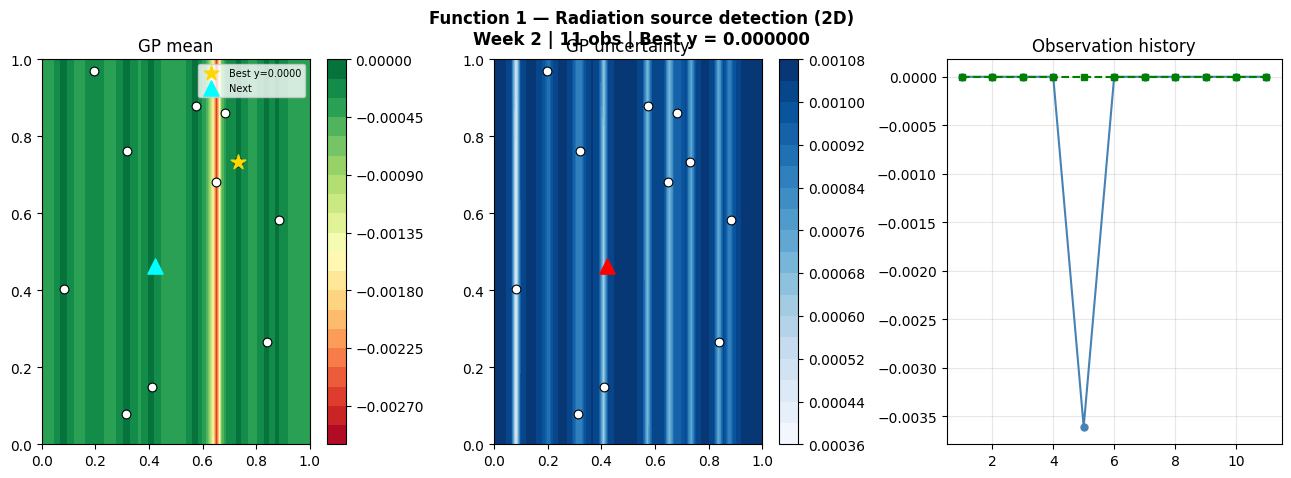

  Plot saved: function_1_week2_analysis.png
Plotting F2...


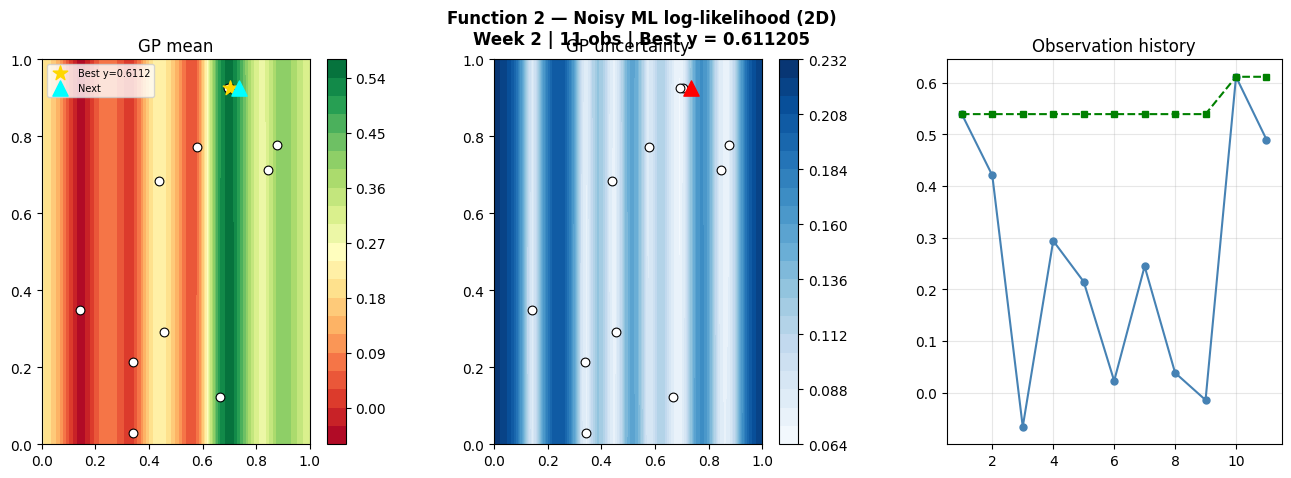

  Plot saved: function_2_week2_analysis.png
Plotting F3...


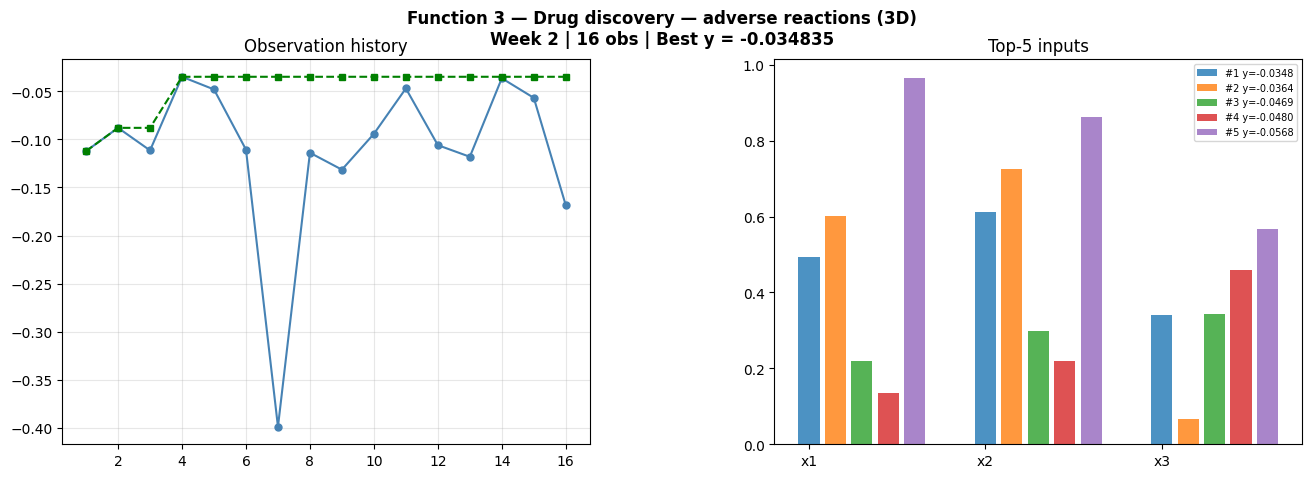

  Plot saved: function_3_week2_analysis.png
Plotting F4...


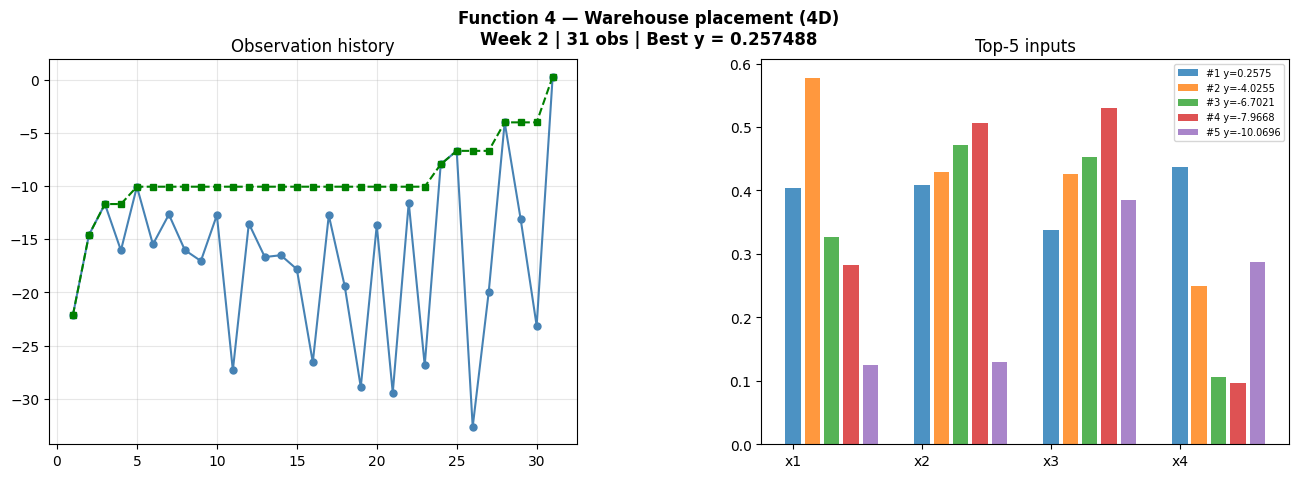

  Plot saved: function_4_week2_analysis.png
Plotting F5...


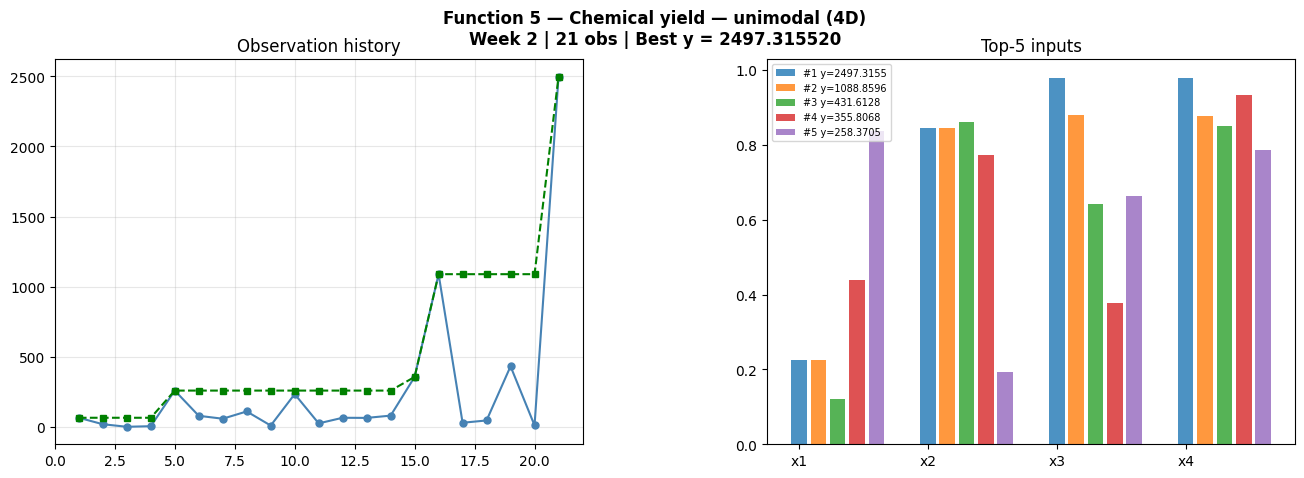

  Plot saved: function_5_week2_analysis.png
Plotting F6...


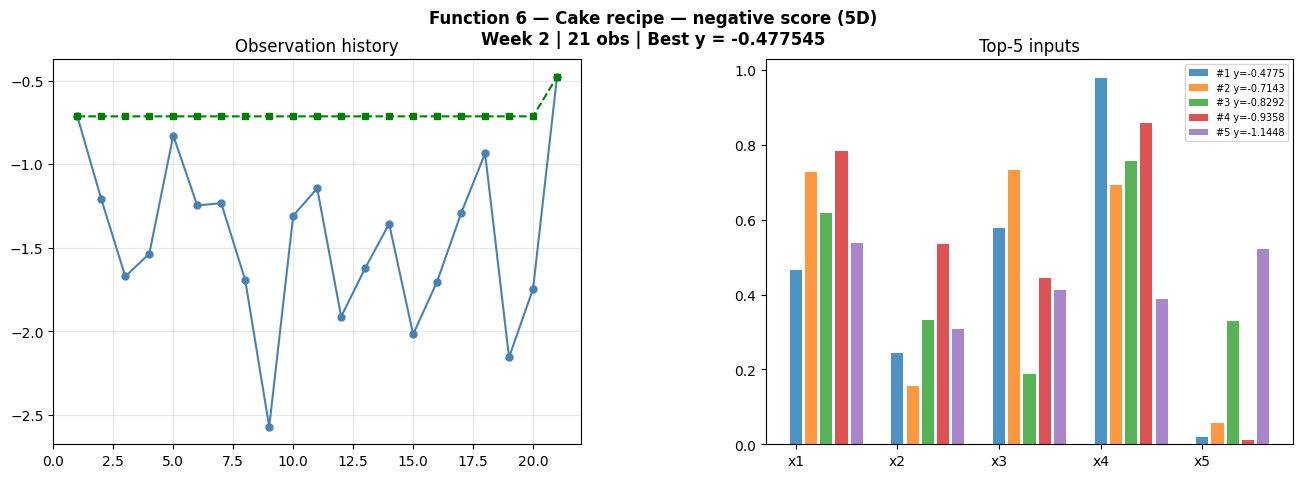

  Plot saved: function_6_week2_analysis.png
Plotting F7...


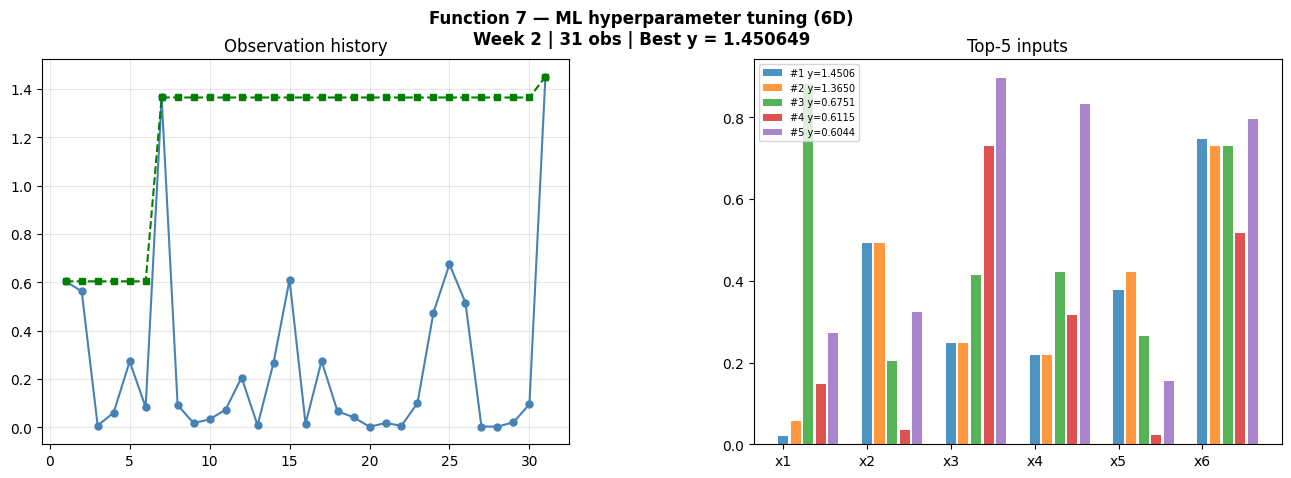

  Plot saved: function_7_week2_analysis.png
Plotting F8...


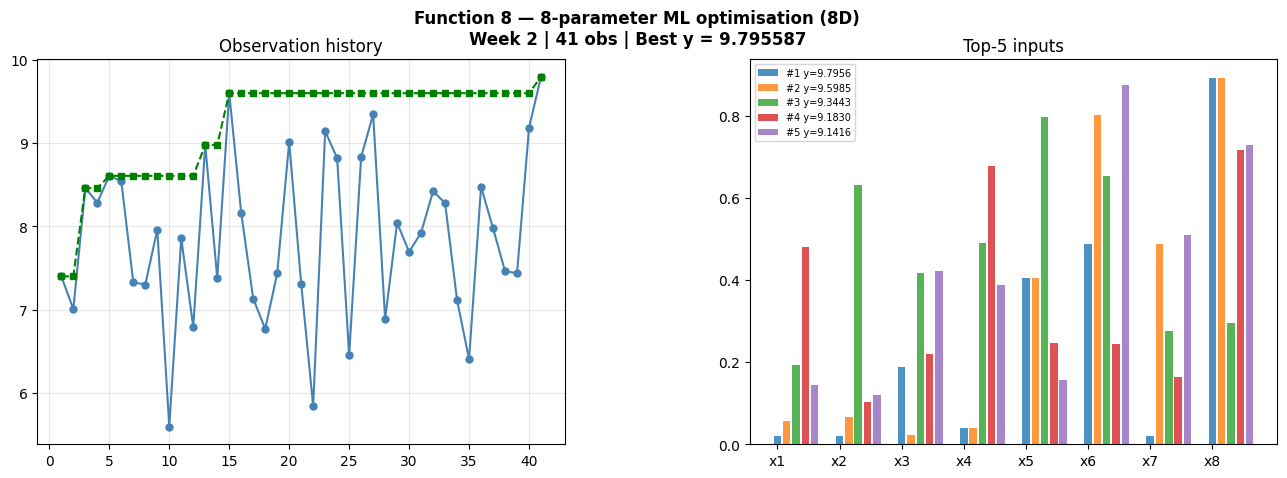

  Plot saved: function_8_week2_analysis.png


In [6]:
def plot_function_summary(fn_id, X, Y, result=None, week=None):
    dim = FUNCTIONS[fn_id]["dim"]
    desc = FUNCTIONS[fn_id]["description"]
    n_obs = len(Y)

    fig = plt.figure(figsize=(16, 5))
    fig.suptitle(
        f"Function {fn_id} — {desc}\n"
        f"Week {week or '?'} | {n_obs} obs | Best y = {Y.max():.6f}",
        fontsize=12, fontweight="bold",
    )

    if dim == 2:
        gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)
        ax1 = fig.add_subplot(gs[0])
        res_grid = 50
        g = np.linspace(0, 1, res_grid)
        G1, G2 = np.meshgrid(g, g)
        grid_pts = np.column_stack([G1.ravel(), G2.ravel()])
        try:
            gp, _ = fit_gp(X, Y, FUNCTIONS[fn_id])
            mu_grid, sig_grid = gp.predict(grid_pts, return_std=True)
            mu_map = mu_grid.reshape(res_grid, res_grid)
            sig_map = sig_grid.reshape(res_grid, res_grid)
            im1 = ax1.contourf(G1, G2, mu_map, levels=20, cmap="RdYlGn")
            plt.colorbar(im1, ax=ax1)
            ax1.scatter(X[:, 0], X[:, 1], c="white", s=40, edgecolors="black", linewidths=0.8)
            bi = int(np.argmax(Y))
            ax1.scatter(X[bi, 0], X[bi, 1], c="gold", s=120, marker="*", label=f"Best y={Y.max():.4f}")
            if result:
                ax1.scatter(result["x_next"][0], result["x_next"][1], c="cyan", s=120, marker="^", label="Next")
            ax1.set_title("GP mean"); ax1.legend(fontsize=7)

            ax2 = fig.add_subplot(gs[1])
            im2 = ax2.contourf(G1, G2, sig_map, levels=20, cmap="Blues")
            plt.colorbar(im2, ax=ax2)
            ax2.scatter(X[:, 0], X[:, 1], c="white", s=40, edgecolors="black", linewidths=0.8)
            if result:
                ax2.scatter(result["x_next"][0], result["x_next"][1], c="red", s=120, marker="^")
            ax2.set_title("GP uncertainty")
        except Exception as e:
            ax1.text(0.5, 0.5, str(e), transform=ax1.transAxes, ha="center")
            ax2 = fig.add_subplot(gs[1])

        ax3 = fig.add_subplot(gs[2])
        ax3.plot(range(1, n_obs + 1), Y, "o-", color="steelblue", markersize=5)
        ax3.plot(range(1, n_obs + 1), [max(Y[: i + 1]) for i in range(n_obs)], "s--", color="green", markersize=4)
        ax3.set_title("Observation history"); ax3.grid(True, alpha=0.3)
    else:
        gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)
        ax1 = fig.add_subplot(gs[0])
        ax1.plot(range(1, n_obs + 1), Y, "o-", color="steelblue", markersize=5)
        ax1.plot(range(1, n_obs + 1), [max(Y[: i + 1]) for i in range(n_obs)], "s--", color="green", markersize=4)
        ax1.set_title("Observation history"); ax1.grid(True, alpha=0.3)
        ax2 = fig.add_subplot(gs[1])
        top_k = min(5, n_obs)
        top_idx = np.argsort(Y)[-top_k:][::-1]
        for rank, idx in enumerate(top_idx):
            ax2.bar(np.arange(dim) + rank * 0.15, X[idx], 0.12, label=f"#{rank+1} y={Y[idx]:.4f}", alpha=0.8)
        ax2.set_xticks(np.arange(dim))
        ax2.set_xticklabels([f"x{i+1}" for i in range(dim)])
        ax2.set_title(f"Top-{top_k} inputs"); ax2.legend(fontsize=7)

    plt.tight_layout()
    out = f"function_{fn_id}_week{week or 0}_analysis.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Plot saved: {out}")


for fn_id, data in results.items():
    print(f"Plotting F{fn_id}...")
    plot_function_summary(fn_id, data["X"], data["Y"], result=data["result"], week=CURRENT_WEEK)


## 6. Veri Guncelleme — Email Sonrasi


In [7]:
# Email'den gelen y degerlerini buraya yaz
EMAIL_RESULTS = {
    1: None,
    2: None,
    3: None,
    4: None,
    5: None,
    6: None,
    7: None,
    8: None,
}

print(f"Hafta {CURRENT_WEEK} veri guncelleme...")
print()

for fn_id, y_new in EMAIL_RESULTS.items():
    if y_new is None:
        print(f"  F{fn_id}: atlandi (deger yok)")
        continue
    if fn_id not in results:
        print(f"  F{fn_id}: atlandi (once haftalik analizi calistir)")
        continue

    X_old = results[fn_id]["X"]
    Y_old = results[fn_id]["Y"]
    x_sub = results[fn_id]["result"]["x_next"]

    X_new = np.vstack([X_old, x_sub.reshape(1, -1)])
    Y_new = np.append(Y_old, y_new)
    save_data(fn_id, X_new, Y_new)

    improved = y_new > Y_old.max()
    print(f"  F{fn_id}: y={y_new:.8e} | {'IYILESTI' if improved else 'iyilesmedi'} | best={Y_new.max():.8e}")

print()
print("Tamamlandi. CURRENT_WEEK += 1 yapip haftalik analizi tekrar calistir.")


Hafta 2 veri guncelleme...

  F1: atlandi (deger yok)
  F2: atlandi (deger yok)
  F3: atlandi (deger yok)
  F4: atlandi (deger yok)
  F5: atlandi (deger yok)
  F6: atlandi (deger yok)
  F7: atlandi (deger yok)
  F8: atlandi (deger yok)

Tamamlandi. CURRENT_WEEK += 1 yapip haftalik analizi tekrar calistir.


## 7. Ilerleme Ozeti


ILERLEME OZETI
Fn   Dim   Init   Query   Best Y             Best X (ilk 2)
------------------------------------------------------------------------
F1   2     10     1       7.71087511e-16     [0.7310  0.7330]
F2   2     10     1       6.11205216e-01     [0.7026  0.9266]
F3   3     15     1       -3.48353134e-02    [0.4926  0.6116 ...]
F4   4     30     1       2.57488102e-01     [0.4040  0.4080 ...]
F5   4     20     1       2.49731552e+03     [0.2242  0.8465 ...]
F6   5     20     1       -4.77544515e-01    [0.4656  0.2431 ...]
F7   6     30     1       1.45064932e+00     [0.0200  0.4917 ...]
F8   8     40     1       9.79558721e+00     [0.0200  0.0200 ...]


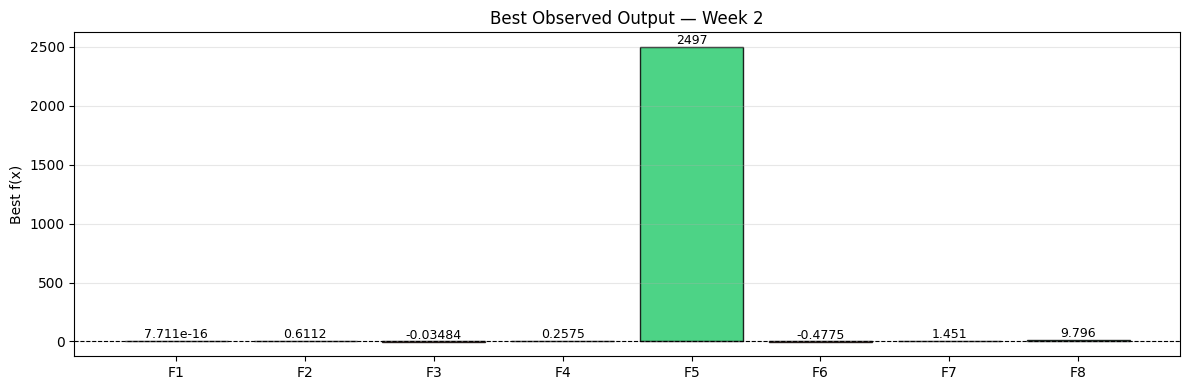

In [8]:
print("=" * 72)
print("ILERLEME OZETI")
print("=" * 72)
print(f"{'Fn':<4} {'Dim':<5} {'Init':<6} {'Query':<7} {'Best Y':<18} {'Best X (ilk 2)'}")
print("-" * 72)
all_best = {}
for fn_id in range(1, 9):
    cfg = FUNCTIONS[fn_id]
    try:
        X, Y = load_data(fn_id)
        n_q = len(Y) - cfg["n_init"]
        best_y = Y.max()
        best_x = X[np.argmax(Y)]
        xs = "  ".join(f"{v:.4f}" for v in best_x[:2])
        if cfg["dim"] > 2:
            xs += " ..."
        print(f"F{fn_id:<3} {cfg['dim']:<5} {cfg['n_init']:<6} {n_q:<7} {best_y:<18.8e} [{xs}]")
        all_best[fn_id] = best_y
    except FileNotFoundError:
        print(f"F{fn_id:<3} {cfg['dim']:<5}  dosya yok")

if all_best:
    fig, ax = plt.subplots(figsize=(12, 4))
    fn_ids = list(all_best.keys())
    ys = list(all_best.values())
    colors = ["#2ecc71" if y > 0 else "#e74c3c" for y in ys]
    bars = ax.bar([f"F{i}" for i in fn_ids], ys, color=colors, edgecolor="black", alpha=0.85)
    for bar, y in zip(bars, ys):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{y:.4g}", ha="center", va="bottom", fontsize=9)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(f"Best Observed Output — Week {CURRENT_WEEK}")
    ax.set_ylabel("Best f(x)")
    ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.savefig(f"progress_week{CURRENT_WEEK}.png", dpi=150, bbox_inches="tight")
    plt.show()


## 8. Tek Fonksiyon Derin Analiz


In [9]:
FOCUS_FN = 1

X, Y = load_data(FOCUS_FN)
cfg = FUNCTIONS[FOCUS_FN]
print(f"F{FOCUS_FN} ({cfg['dim']}D): {cfg['description']}")
print(f"Gozlem: {len(Y)} | Y max: {Y.max():.8e}")
print()

sorted_idx = np.argsort(Y)[::-1]
for rank, idx in enumerate(sorted_idx[:10]):
    xs = "  ".join(f"{v:.4f}" for v in X[idx])
    print(f"  #{rank+1:2d}  y={Y[idx]:+.8e}  x=[{xs}]")

print()
rec = find_next_query(FOCUS_FN, X, Y, CURRENT_WEEK)
print(f"Onerilen: {format_submission(rec['x_next'])}")
print(f"  Mod: {rec['mode']}")
print(f"  AF: {rec['af_label']}")


F1 (2D): Radiation source detection (2D)
Gozlem: 11 | Y max: 7.71087511e-16

  # 1  y=+7.71087511e-16  x=[0.7310  0.7330]
  # 2  y=+2.53500115e-40  x=[0.6834  0.8611]
  # 3  y=+1.03307824e-46  x=[0.5743  0.8799]
  # 4  y=+6.22985647e-48  x=[0.8839  0.5823]
  # 5  y=+1.32267704e-79  x=[0.3194  0.7630]
  # 6  y=+3.60677119e-81  x=[0.0825  0.4035]
  # 7  y=+3.34177101e-124  x=[0.8404  0.2647]
  # 8  y=+4.84631951e-214  x=[0.1964  0.9707]
  # 9  y=-2.08909327e-91  x=[0.3127  0.0787]
  #10  y=-2.15924904e-54  x=[0.4104  0.1476]



Onerilen: 0.421062-0.463562
  Mod: COVERAGE [sinyal yok, anti-boundary]
  AF: EXPLORATION [sinyal yok, exploration]
